<a href="https://colab.research.google.com/github/benniella/Ml-learning/blob/main/Customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('customer.csv')
df.head()

,CustomerID,RentalFrequency,AverageRentalDuration,SatisfactionScore,TotalRevenue,LoyaltyProgram,Complaints,Churned
0,1,14,8,9,2740,No,8,0
1,2,5,6,7,1749,No,3,1
2,3,19,7,4,1445,No,6,1
3,4,28,9,5,3056,No,7,0
4,5,28,7,5,2546,No,5,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CustomerID             1000 non-null   int64 
 1   RentalFrequency        1000 non-null   int64 
 2   AverageRentalDuration  1000 non-null   int64 
 3   SatisfactionScore      1000 non-null   int64 
 4   TotalRevenue           1000 non-null   int64 
 5   LoyaltyProgram         1000 non-null   object
 6   Complaints             1000 non-null   int64 
 7   Churned                1000 non-null   int64 
dtypes: int64(7), object(1)
memory usage: 62.6+ KB


In [ ]:
def preprocess_text(text):
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize
    words = word_tokenize(text)
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    # Lemmatize words
    words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(words)

In [ ]:
X = df[['RentalFrequency', 'AverageRentalDuration', 'SatisfactionScore', 'TotalRevenue']]
y = df['Churned']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [ ]:
scaler = StandardScaler()
X_train_smote = scaler.fit_transform(X_train_smote)
X_test = scaler.transform(X_test)


In [ ]:
rf_model_smote = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model_smote.fit(X_train_smote, y_train_smote)


RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf_smote = rf_model_smote.predict(X_test)


In [ ]:
y_pred = model.predict(X_test)


In [ ]:
y_pred_weighted = model_weighted.predict(X_test)

In [ ]:
accuracy_rf_smote = accuracy_score(y_test, y_pred_rf_smote)
print(f'Accuracy (Random Forest with SMOTE): {accuracy_rf_smote:.2f}')
print('Confusion Matrix (Random Forest with SMOTE):')
print(confusion_matrix(y_test, y_pred_rf_smote))
print('Classification Report (Random Forest with SMOTE):')
print(classification_report(y_test, y_pred_rf_smote))

Accuracy (Random Forest with SMOTE): 0.63
Confusion Matrix (Random Forest with SMOTE):
[[117  42]
 [ 32   9]]
Classification Report (Random Forest with SMOTE):
              precision    recall  f1-score   support

           0       0.79      0.74      0.76       159
           1       0.18      0.22      0.20        41

    accuracy                           0.63       200
   macro avg       0.48      0.48      0.48       200
weighted avg       0.66      0.63      0.64       200



In [ ]:
feature_importances = rf_model_smote.feature_importances_
features = X.columns



<ipython-input-13-a86322bc23ad>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=features, palette='viridis')


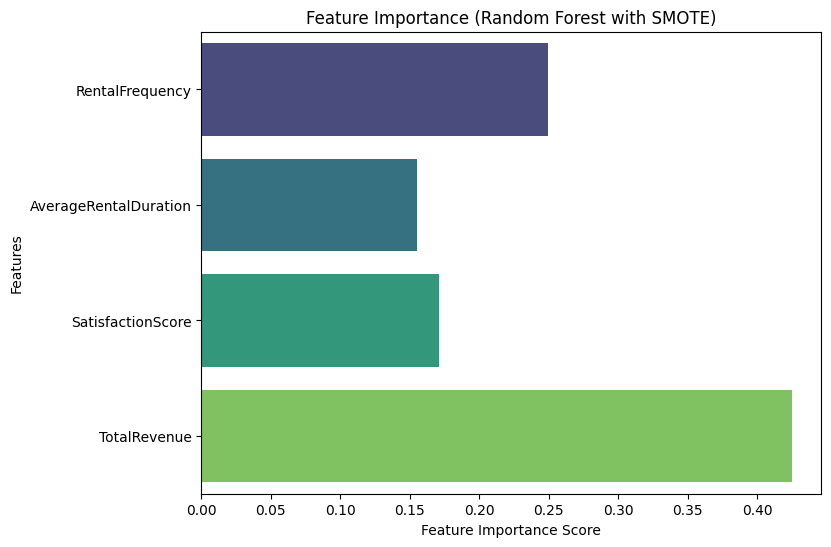

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x=feature_importances, y=features, palette='viridis')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance (Random Forest with SMOTE)')
plt.show()

<ipython-input-15-1badbe087316>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churned', data=df, palette='viridis')


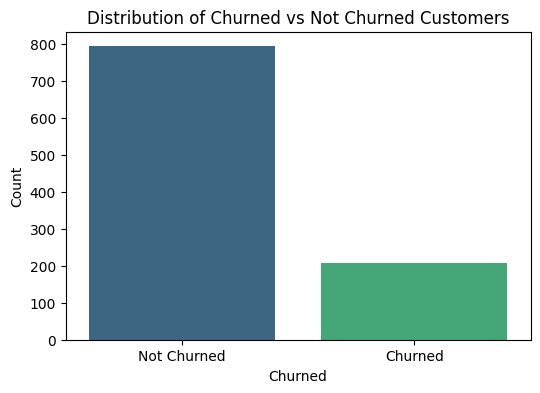

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churned', data=df, palette='viridis')
plt.title('Distribution of Churned vs Not Churned Customers')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.show()



<ipython-input-18-6d908ec2682d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churned', y='TotalRevenue', palette='viridis')


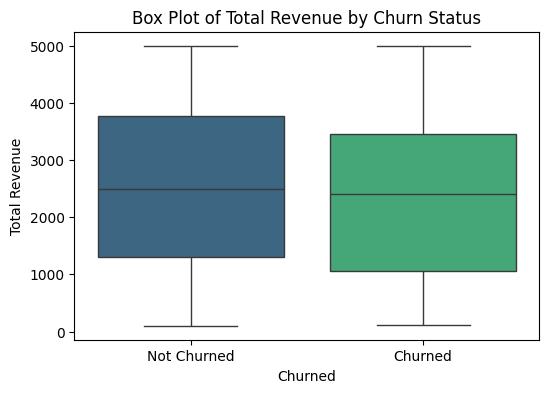

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Churned', y='TotalRevenue', palette='viridis')
plt.title('Box Plot of Total Revenue by Churn Status')
plt.xlabel('Churned')
plt.ylabel('Total Revenue')
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.show()

In [ ]:
numerical_columns = df.select_dtypes(include=['number'])
correlation_matrix = numerical_columns.corr()

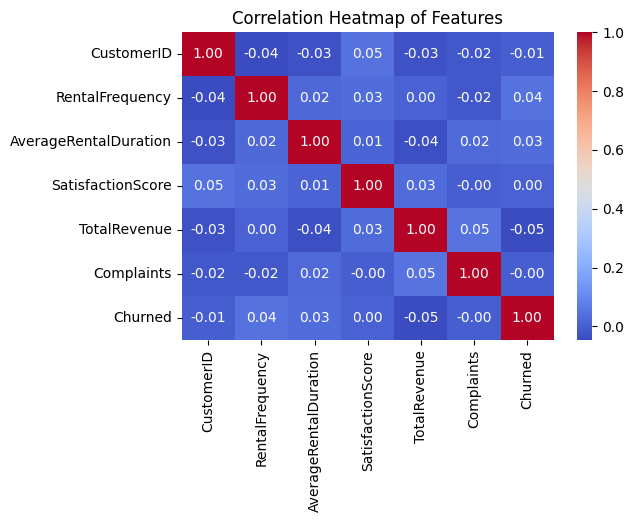

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()